# 18. Dataclasses & Containers — Backend Data Modeling

Interviews at companies like ServiceTitan often include a "design a custom data structure"
round (e.g. the MultiMap HackerRank problem). The underlying pattern is always the same:

```
API JSON → Dataclass (single record) → Container (manages many records, multiple indexes)
```

This notebook builds that pattern from scratch, then extends it to production-quality
complexity with time indexing, removal, mutation, and concurrency discussion.

## Contents
1. Why this pattern exists
2. Dataclasses — structured records
3. Simulating API data ingestion
4. Container with multiple indexes
5. Time-sorted index with `bisect`
6. Job removal — keeping indexes consistent
7. Mutation — what happens when a job changes
8. Complexity analysis
9. Interview practice: full implementation
10. Bonus: `get_next_job_for_technician`


---
## Part 1 — Why This Pattern Exists

Every backend service that receives data follows this pipeline:

```
POST /jobs  →  JSON payload  →  Job dataclass  →  JobStore container
```

The **dataclass** gives you type safety, clean attribute access, and `__repr__` for free.
The **container** wraps one or more dicts/lists to give fast lookup across multiple axes.

This exact pattern appears in:
- ServiceTitan's dispatch/scheduling backend
- Any trading system (order books)
- Real-time dashboards (time-indexed events)
- The HackerRank MultiMap problem


## Part 2 — Creating a Dataclass

In [1]:
from dataclasses import dataclass, field
from datetime import datetime
from typing import List, Optional
import bisect, threading, copy

@dataclass
class Job:
    job_id: str
    technician_id: str
    customer_id: str
    scheduled_start: datetime
    duration_minutes: int
    required_parts: List[str]

# Instantiate one directly
job_direct = Job(
    job_id="J100",
    technician_id="T42",
    customer_id="C88",
    scheduled_start=datetime(2026, 3, 10, 9, 0),
    duration_minutes=90,
    required_parts=["relay", "compressor"]
)

print(job_direct)
print()
print(f"  job_id:          {job_direct.job_id}")
print(f"  technician_id:   {job_direct.technician_id}")
print(f"  scheduled_start: {job_direct.scheduled_start}")
print(f"  duration:        {job_direct.duration_minutes} min")


Job(job_id='J100', technician_id='T42', customer_id='C88', scheduled_start=datetime.datetime(2026, 3, 10, 9, 0), duration_minutes=90, required_parts=['relay', 'compressor'])

  job_id:          J100
  technician_id:   T42
  scheduled_start: 2026-03-10 09:00:00
  duration:        90 min


---
## Part 3 — Simulating API Data Ingestion

Real services receive JSON. The standard pattern is to parse JSON then construct
the dataclass — keeping the business logic layer clean from serialization details.


In [2]:
# Simulated API payloads — this is what arrives from POST /jobs

api_payloads = [
    {
        "job_id": "J101",
        "technician_id": "T11",
        "customer_id": "C52",
        "scheduled_start": "2026-03-10T10:00:00",
        "duration_minutes": 60,
        "required_parts": ["valve"]
    },
    {
        "job_id": "J102",
        "technician_id": "T11",
        "customer_id": "C99",
        "scheduled_start": "2026-03-10T08:00:00",
        "duration_minutes": 45,
        "required_parts": ["filter", "belt"]
    },
    {
        "job_id": "J103",
        "technician_id": "T42",
        "customer_id": "C14",
        "scheduled_start": "2026-03-10T14:00:00",
        "duration_minutes": 120,
        "required_parts": ["compressor"]
    },
    {
        "job_id": "J104",
        "technician_id": "T11",
        "customer_id": "C77",
        "scheduled_start": "2026-03-10T13:00:00",
        "duration_minutes": 30,
        "required_parts": []
    },
]

def job_from_api(payload: dict) -> Job:
    """Convert raw API JSON dict → Job dataclass."""
    return Job(
        job_id          = payload["job_id"],
        technician_id   = payload["technician_id"],
        customer_id     = payload["customer_id"],
        scheduled_start = datetime.fromisoformat(payload["scheduled_start"]),
        duration_minutes= payload["duration_minutes"],
        required_parts  = payload["required_parts"]
    )

jobs = [job_from_api(p) for p in api_payloads]
for j in jobs:
    print(f"  {j.job_id}  tech={j.technician_id}  start={j.scheduled_start.strftime('%H:%M')}")


  J101  tech=T11  start=10:00
  J102  tech=T11  start=08:00
  J103  tech=T42  start=14:00
  J104  tech=T11  start=13:00


---
## Part 4 — Container with Multiple Indexes

A container wraps **multiple dicts/lists** so every query path is O(1) or O(log n).
Without a container you'd scan all jobs on every lookup — O(n) per query.

```
JobStore
 ├── jobs_by_id          dict[str → Job]          O(1) lookup by job_id
 ├── jobs_by_technician  dict[str → list[Job]]    O(k) list for a technician
 └── jobs_by_time        sorted list[(dt, Job)]   O(log n) insert, range queries
```

The cost: **every write must update all indexes**. This is the tradeoff
interviewers want you to articulate.


In [3]:
class JobStore:
    """In-memory store with three indexes."""

    def __init__(self):
        self.jobs_by_id         : dict             = {}   # job_id -> Job
        self.jobs_by_technician : dict             = {}   # tech_id -> [Job, ...]
        self.jobs_by_time       : list             = []   # [(datetime, Job), ...] sorted

    # ── Write ────────────────────────────────────────────────────────────────

    def add_job(self, job: Job) -> None:
        if job.job_id in self.jobs_by_id:
            raise ValueError(f"Job {job.job_id} already exists. Use update_job.")

        # Index 1: by ID
        self.jobs_by_id[job.job_id] = job

        # Index 2: by technician
        self.jobs_by_technician.setdefault(job.technician_id, []).append(job)

        # Index 3: sorted by time
        bisect.insort(self.jobs_by_time, (job.scheduled_start, job.job_id, job))

    # ── Read ─────────────────────────────────────────────────────────────────

    def get_job(self, job_id: str) -> Optional[Job]:
        return self.jobs_by_id.get(job_id)

    def get_jobs_for_technician(self, tech_id: str) -> List[Job]:
        """Returns jobs sorted by scheduled_start."""
        jobs = self.jobs_by_technician.get(tech_id, [])
        return sorted(jobs, key=lambda j: j.scheduled_start)

    def get_all_sorted_by_time(self) -> List[Job]:
        return [j for _, _, j in self.jobs_by_time]


# ── Smoke test ────────────────────────────────────────────────────────────────
store = JobStore()
for j in jobs:
    store.add_job(j)

# Add the manually-created job too
store.add_job(job_direct)

print("All jobs sorted by time:")
for j in store.get_all_sorted_by_time():
    print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}  tech={j.technician_id}")

print()
print("T11 schedule:")
for j in store.get_jobs_for_technician("T11"):
    print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}")


All jobs sorted by time:
  08:00  J102  tech=T11
  09:00  J100  tech=T42
  10:00  J101  tech=T11
  13:00  J104  tech=T11
  14:00  J103  tech=T42

T11 schedule:
  08:00  J102
  10:00  J101
  13:00  J104


---
## Part 5 — Why `bisect.insort` Keeps the Time Index Sorted

`bisect` maintains a sorted list without a full re-sort on every insert.

| Operation        | `list.sort()` after insert | `bisect.insort` |
|------------------|---------------------------|-----------------|
| Insert           | O(n log n)                | **O(log n)** find + O(n) shift |
| Iteration        | O(n)                      | O(n)            |
| Range query      | O(n) scan                 | **O(log n)** find start + O(k) read |

The tuple `(datetime, job_id, job)` is used as the sort key — Python compares
tuples left-to-right, so ties on `datetime` break on `job_id` (a string), which
prevents errors when two jobs start at the same time.


In [4]:
# Demonstrate bisect behavior directly

import bisect

times = []
arrivals = [
    datetime(2026, 3, 10, 14, 0),
    datetime(2026, 3, 10, 8,  0),
    datetime(2026, 3, 10, 10, 0),
    datetime(2026, 3, 10, 9,  0),
]

for t in arrivals:
    bisect.insort(times, t)
    print(f"  Inserted {t.strftime('%H:%M')}  →  list: {[x.strftime('%H:%M') for x in times]}")

print()
print("List is always sorted — no explicit sort() call needed.")
print(f"bisect.bisect_left for range query start: O(log n) = O(log {len(times)})")


  Inserted 14:00  →  list: ['14:00']
  Inserted 08:00  →  list: ['08:00', '14:00']
  Inserted 10:00  →  list: ['08:00', '10:00', '14:00']
  Inserted 09:00  →  list: ['08:00', '09:00', '10:00', '14:00']

List is always sorted — no explicit sort() call needed.
bisect.bisect_left for range query start: O(log n) = O(log 4)


---
## Part 6 — Job Removal — Keeping All Indexes Consistent

Removal is the hard part. You must clean up **every** index or you get stale data.

Common interview mistake: removing from `jobs_by_id` but forgetting to remove from
`jobs_by_technician` and `jobs_by_time`.

**Removal complexity:**
- `jobs_by_id`: O(1) dict delete
- `jobs_by_technician`: O(k) scan the technician's list to find and remove
- `jobs_by_time`: O(log n) find via bisect + O(n) list removal (shift)


In [5]:
class JobStore(JobStore):  # extend in place for notebook clarity
    
    def remove_job(self, job_id: str) -> Optional[Job]:
        """Remove job from all indexes. Returns removed job or None if not found."""
        job = self.jobs_by_id.pop(job_id, None)
        if job is None:
            return None

        # Index 2: remove from technician list
        tech_jobs = self.jobs_by_technician.get(job.technician_id, [])
        try:
            tech_jobs.remove(job)          # O(k) scan
        except ValueError:
            pass
        if not tech_jobs:
            del self.jobs_by_technician[job.technician_id]

        # Index 3: remove from time-sorted list
        # bisect finds the insertion point; scan forward for the exact tuple
        key = (job.scheduled_start, job.job_id, job)
        idx = bisect.bisect_left(self.jobs_by_time, key)
        while idx < len(self.jobs_by_time):
            if self.jobs_by_time[idx][2].job_id == job_id:
                self.jobs_by_time.pop(idx)  # O(n) shift — acceptable for moderate n
                break
            idx += 1

        return job


# Rebuild store with the extended class
store = JobStore()
for j in jobs:
    store.add_job(j)
store.add_job(job_direct)

print("Before removal:")
for j in store.get_all_sorted_by_time():
    print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}")

removed = store.remove_job("J102")
print(f"\nRemoved: {removed.job_id}")

print("\nAfter removal:")
for j in store.get_all_sorted_by_time():
    print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}")

print("\nT11 schedule after removal:")
for j in store.get_jobs_for_technician("T11"):
    print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}")


Before removal:
  08:00  J102
  09:00  J100
  10:00  J101
  13:00  J104
  14:00  J103

Removed: J102

After removal:
  09:00  J100
  10:00  J101
  13:00  J104
  14:00  J103

T11 schedule after removal:
  10:00  J101
  13:00  J104


---
## Part 7 — Mutation — What Happens When a Job Changes

If a job's `scheduled_start` or `technician_id` changes, **the indexes become
stale** unless you update them. The clean pattern is:

```
update_job = remove_job(old) + add_job(new)
```

This guarantees consistency at the cost of two O(n) operations.
An alternative is an **in-place patch with targeted index surgery** — faster but
error-prone and harder to test.


In [6]:
class JobStore(JobStore):

    def update_job(self, job_id: str, **updates) -> Optional[Job]:
        """
        Update fields on an existing job.
        Re-inserts into all affected indexes.
        
        Example:
            store.update_job("J101", scheduled_start=new_time, duration_minutes=90)
        """
        old_job = self.remove_job(job_id)
        if old_job is None:
            return None

        # Build updated job via dataclass replace-style (manual here for clarity)
        old_dict = {
            "job_id":           old_job.job_id,
            "technician_id":    old_job.technician_id,
            "customer_id":      old_job.customer_id,
            "scheduled_start":  old_job.scheduled_start,
            "duration_minutes": old_job.duration_minutes,
            "required_parts":   old_job.required_parts,
        }
        old_dict.update(updates)
        new_job = Job(**old_dict)
        self.add_job(new_job)
        return new_job


# Demo: reschedule J101 from 10:00 to 07:30
store = JobStore()
for j in jobs:
    store.add_job(j)

print("Before update — T11 schedule:")
for j in store.get_jobs_for_technician("T11"):
    print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}")

store.update_job("J101", scheduled_start=datetime(2026, 3, 10, 7, 30))

print("\nAfter rescheduling J101 to 07:30:")
for j in store.get_jobs_for_technician("T11"):
    print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}")

print("\nAll jobs sorted (time index integrity check):")
for j in store.get_all_sorted_by_time():
    print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}  tech={j.technician_id}")


Before update — T11 schedule:
  08:00  J102
  10:00  J101
  13:00  J104

After rescheduling J101 to 07:30:
  07:30  J101
  08:00  J102
  13:00  J104

All jobs sorted (time index integrity check):
  07:30  J101  tech=T11
  08:00  J102  tech=T11
  13:00  J104  tech=T11
  14:00  J103  tech=T42


---
## Part 8 — Complexity Analysis

This is what interviewers listen for. State it proactively.

| Operation                        | Time Complexity | Notes |
|----------------------------------|-----------------|-------|
| `add_job`                        | O(log n)        | Dominated by `bisect.insort` |
| `get_job(job_id)`                | O(1)            | Dict lookup |
| `get_jobs_for_technician`        | O(k log k)      | k = jobs for that tech, sorted |
| `remove_job`                     | O(n)            | List shift in time index is O(n) worst-case |
| `update_job`                     | O(n)            | remove + add |
| Time range query                 | O(log n + k)    | bisect find + k results |

**Space**: O(n × m) where m = number of indexes (here m=3). Each job reference is
stored once per index — Python holds references not copies, so memory overhead is
just the pointer size per extra index.

**When would you replace the sorted list?**
- For write-heavy workloads: use a **SortedList** from the `sortedcontainers` package (O(log n) removal)
- For very high concurrency: use a **skip list** or a database B-tree index
- For pure in-memory: a **heap** works if you only need min/max, not range queries


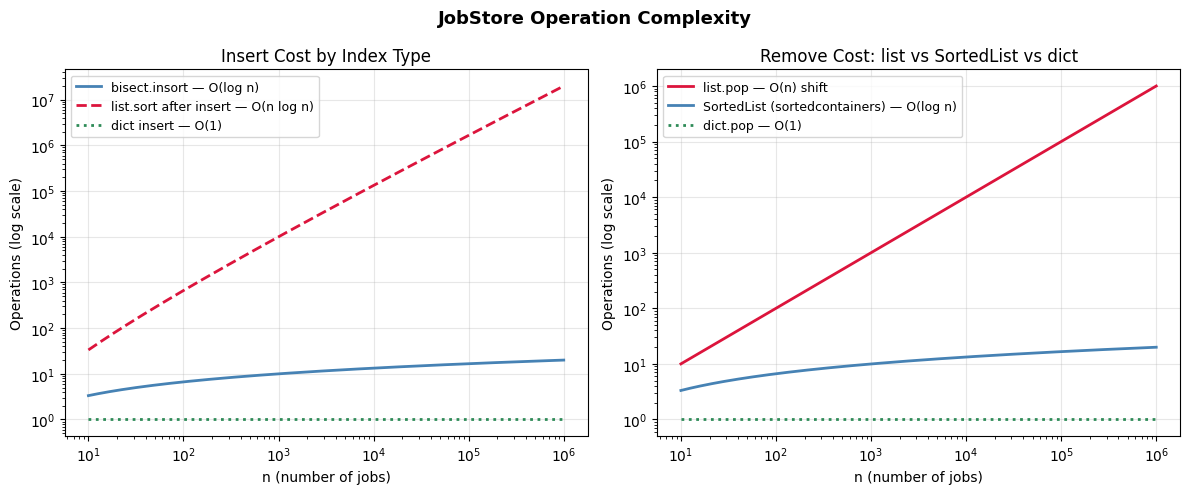

Saved: 18a_complexity.png


In [7]:
# Visualize the complexity tradeoffs

import matplotlib.pyplot as plt
import numpy as np

ns = np.logspace(1, 6, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: insert cost
axes[0].plot(ns, np.log2(ns),       label='bisect.insort — O(log n)',       color='steelblue', lw=2)
axes[0].plot(ns, ns * np.log2(ns),  label='list.sort after insert — O(n log n)', color='crimson', lw=2, linestyle='--')
axes[0].plot(ns, np.ones_like(ns),  label='dict insert — O(1)',             color='seagreen',  lw=2, linestyle=':')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('n (number of jobs)')
axes[0].set_ylabel('Operations (log scale)')
axes[0].set_title('Insert Cost by Index Type')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: remove cost — sorted list vs SortedList
axes[1].plot(ns, ns,                 label='list.pop — O(n) shift',                  color='crimson',    lw=2)
axes[1].plot(ns, np.log2(ns),        label='SortedList (sortedcontainers) — O(log n)', color='steelblue', lw=2)
axes[1].plot(ns, np.ones_like(ns),   label='dict.pop — O(1)',                        color='seagreen',   lw=2, linestyle=':')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('n (number of jobs)')
axes[1].set_ylabel('Operations (log scale)')
axes[1].set_title('Remove Cost: list vs SortedList vs dict')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle('JobStore Operation Complexity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('18a_complexity.png', dpi=120)
plt.show()
print("Saved: 18a_complexity.png")


---
## Part 9 — Interview Practice: Full Implementation

This is the complete solution for the interview problem:

> Design a container that supports:
> 1. Add job
> 2. Remove job  
> 3. Lookup by job ID — O(1)
> 4. Lookup technician schedule sorted by time — O(k log k)
> 5. What about concurrent updates?

The concurrency answer: wrap mutating operations with a `threading.Lock`.
This is the in-memory equivalent of a row-level lock in a database.


In [8]:
class ProductionJobStore:
    """
    Thread-safe in-memory job store.

    Indexes:
        jobs_by_id:         dict[str, Job]         O(1) lookup
        jobs_by_technician: dict[str, list[Job]]   O(k) per technician
        jobs_by_time:       list[(dt, job_id, Job)] maintained sorted

    Thread safety: coarse-grained lock on all mutations.
    In production: shard by technician_id to reduce contention.
    """

    def __init__(self):
        self._jobs_by_id         : dict = {}
        self._jobs_by_technician : dict = {}
        self._jobs_by_time       : list = []
        self._lock = threading.Lock()

    # ── Write ────────────────────────────────────────────────────────────────

    def add_job(self, job: Job) -> None:
        with self._lock:
            if job.job_id in self._jobs_by_id:
                raise ValueError(f"Duplicate job_id: {job.job_id}")
            self._jobs_by_id[job.job_id] = job
            self._jobs_by_technician.setdefault(job.technician_id, []).append(job)
            bisect.insort(self._jobs_by_time, (job.scheduled_start, job.job_id, job))

    def remove_job(self, job_id: str) -> Optional[Job]:
        with self._lock:
            return self._remove_job_unsafe(job_id)

    def _remove_job_unsafe(self, job_id: str) -> Optional[Job]:
        """Must be called with lock held."""
        job = self._jobs_by_id.pop(job_id, None)
        if job is None:
            return None
        # Technician index
        tech_list = self._jobs_by_technician.get(job.technician_id, [])
        try:
            tech_list.remove(job)
        except ValueError:
            pass
        if not tech_list:
            self._jobs_by_technician.pop(job.technician_id, None)
        # Time index
        key = (job.scheduled_start, job.job_id, job)
        idx = bisect.bisect_left(self._jobs_by_time, key)
        while idx < len(self._jobs_by_time):
            if self._jobs_by_time[idx][2].job_id == job_id:
                self._jobs_by_time.pop(idx)
                break
            idx += 1
        return job

    def update_job(self, job_id: str, **updates) -> Optional[Job]:
        with self._lock:
            old = self._remove_job_unsafe(job_id)
            if old is None:
                return None
            merged = {
                "job_id": old.job_id, "technician_id": old.technician_id,
                "customer_id": old.customer_id, "scheduled_start": old.scheduled_start,
                "duration_minutes": old.duration_minutes, "required_parts": old.required_parts,
            }
            merged.update(updates)
            new_job = Job(**merged)
            # Insert directly (already holding lock, can't call add_job)
            self._jobs_by_id[new_job.job_id] = new_job
            self._jobs_by_technician.setdefault(new_job.technician_id, []).append(new_job)
            bisect.insort(self._jobs_by_time, (new_job.scheduled_start, new_job.job_id, new_job))
            return new_job

    # ── Read ─────────────────────────────────────────────────────────────────

    def get_job(self, job_id: str) -> Optional[Job]:
        return self._jobs_by_id.get(job_id)   # dict read is atomic in CPython

    def get_jobs_for_technician(self, tech_id: str) -> List[Job]:
        jobs = self._jobs_by_technician.get(tech_id, [])
        return sorted(jobs, key=lambda j: j.scheduled_start)

    def get_next_job_for_technician(self, tech_id: str) -> Optional[Job]:
        """Bonus: returns the next scheduled job for a technician."""
        now = datetime.now()
        schedule = self.get_jobs_for_technician(tech_id)
        for job in schedule:
            if job.scheduled_start >= now:
                return job
        return None

    def get_all_sorted_by_time(self) -> List[Job]:
        return [j for _, _, j in self._jobs_by_time]

    def __len__(self):
        return len(self._jobs_by_id)

    def __repr__(self):
        return f"ProductionJobStore(n={len(self)})"


# ── Full integration test ─────────────────────────────────────────────────────
pstore = ProductionJobStore()
for j in jobs:
    pstore.add_job(j)
pstore.add_job(job_direct)

print(pstore)
print()

# Test all operations
assert pstore.get_job("J101") is not None,       "get_job failed"
assert pstore.get_job("NOPE") is None,           "get_job should return None for missing"
assert len(pstore.get_jobs_for_technician("T11")) == 3, "T11 should have 3 jobs"

pstore.remove_job("J104")
assert len(pstore.get_jobs_for_technician("T11")) == 2, "T11 should have 2 jobs after remove"
assert pstore.get_job("J104") is None,           "J104 should be gone from ID index"

pstore.update_job("J101", scheduled_start=datetime(2026, 3, 10, 7, 0))
t11 = pstore.get_jobs_for_technician("T11")
assert t11[0].scheduled_start.hour == 7,         "J101 should now be first in T11 schedule"

print("All assertions passed.")
print()
print("Final T11 schedule:")
for j in pstore.get_jobs_for_technician("T11"):
    print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}")

print()
print("Full time-sorted store:")
for j in pstore.get_all_sorted_by_time():
    print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}  tech={j.technician_id}")


ProductionJobStore(n=5)

All assertions passed.

Final T11 schedule:
  07:00  J101
  08:00  J102

Full time-sorted store:
  07:00  J101  tech=T11
  08:00  J102  tech=T11
  09:00  J100  tech=T42
  14:00  J103  tech=T42


---
## Part 10 — Bonus: `get_next_job_for_technician`

The bonus exercise asks: return the *next* upcoming job for a technician.

**Naive approach**: scan the technician's list, find `min(j for j if j.start >= now)` — O(k).

**Optimized approach**: maintain a per-technician sorted list and use `bisect` to find
the insertion point for `now` — O(log k). Worth mentioning in the interview even if
you implement the naive version first.


In [9]:
# Demonstrate get_next_job_for_technician
# Since all our jobs are in 2026-03-10, and 'now' may be after them,
# we override 'now' to show the logic clearly.

import unittest.mock as mock
from datetime import datetime

# Patch datetime.now() to return 09:30 for demo purposes
demo_now = datetime(2026, 3, 10, 9, 30)

class PatchedStore(ProductionJobStore):
    def get_next_job_for_technician(self, tech_id: str) -> Optional[Job]:
        schedule = self.get_jobs_for_technician(tech_id)
        for job in schedule:
            if job.scheduled_start >= demo_now:
                return job
        return None

demo_store = PatchedStore()
for j in jobs:
    demo_store.add_job(j)

print(f"Current time (demo): {demo_now.strftime('%H:%M')}")
print()

for tech_id in ["T11", "T42"]:
    nxt = demo_store.get_next_job_for_technician(tech_id)
    schedule = demo_store.get_jobs_for_technician(tech_id)
    print(f"Tech {tech_id} schedule:")
    for j in schedule:
        marker = " ◀ NEXT" if nxt and j.job_id == nxt.job_id else ""
        past   = " (past)" if j.scheduled_start < demo_now else ""
        print(f"  {j.scheduled_start.strftime('%H:%M')}  {j.job_id}{past}{marker}")
    print()


Current time (demo): 09:30

Tech T11 schedule:
  08:00  J102 (past)
  10:00  J101 ◀ NEXT
  13:00  J104

Tech T42 schedule:
  14:00  J103 ◀ NEXT



In [10]:
# Optimized version: per-technician sorted list for O(log k) next-job lookup

class OptimizedJobStore(ProductionJobStore):
    """
    Extends ProductionJobStore with per-technician sorted lists.
    get_next_job_for_technician: O(log k) instead of O(k).
    Tradeoff: extra memory for per-tech sorted lists; more complex add/remove.
    """

    def __init__(self):
        super().__init__()
        self._tech_sorted: dict = {}   # tech_id -> [(datetime, job_id, Job)]

    def add_job(self, job: Job) -> None:
        super().add_job(job)
        key = (job.scheduled_start, job.job_id, job)
        if job.technician_id not in self._tech_sorted:
            self._tech_sorted[job.technician_id] = []
        bisect.insort(self._tech_sorted[job.technician_id], key)

    def _remove_job_unsafe(self, job_id: str) -> Optional[Job]:
        job = super()._remove_job_unsafe(job_id)
        if job:
            tech_sl = self._tech_sorted.get(job.technician_id, [])
            key = (job.scheduled_start, job.job_id, job)
            idx = bisect.bisect_left(tech_sl, key)
            while idx < len(tech_sl):
                if tech_sl[idx][2].job_id == job_id:
                    tech_sl.pop(idx)
                    break
                idx += 1
        return job

    def get_next_job_for_technician(self, tech_id: str, now=None) -> Optional[Job]:
        """O(log k): binary search into per-technician sorted list."""
        now = now or datetime.now()
        sl = self._tech_sorted.get(tech_id, [])
        # Find first entry with datetime >= now
        pivot = (now, "", None)
        idx = bisect.bisect_left(sl, pivot)
        if idx < len(sl):
            return sl[idx][2]
        return None


ostore = OptimizedJobStore()
for j in jobs:
    ostore.add_job(j)

print("OptimizedJobStore — O(log k) next-job lookup:")
for tech_id in ["T11", "T42"]:
    nxt = ostore.get_next_job_for_technician(tech_id, now=demo_now)
    if nxt:
        print(f"  Tech {tech_id}: next job = {nxt.job_id} at {nxt.scheduled_start.strftime('%H:%M')}")
    else:
        print(f"  Tech {tech_id}: no upcoming jobs")


OptimizedJobStore — O(log k) next-job lookup:
  Tech T11: next job = J101 at 10:00
  Tech T42: next job = J103 at 14:00


---
## Summary

```
Dataclass  = one structured record  (type safety, clean repr, zero boilerplate)
Container  = manager for many records
Indexes    = fast lookup paths       (one dict/list per query axis)
```

**Key interview points to state out loud:**

1. **Every write touches every index** — this is the consistency cost you pay for fast reads
2. **bisect.insort keeps the time index sorted in O(log n)** — no full re-sort on insert
3. **Removal from a sorted list is O(n)** due to the list shift — upgrade to `SortedList` if writes are frequent
4. **Mutation = remove_old + add_new** — the simplest correct pattern
5. **Thread safety**: coarse lock on all mutations; shard by key for lower contention
6. **dataclasses.replace()** is the idiomatic way to clone-with-changes in production

### Relationship to ServiceTitan's Stack
- The Dispatch Pro engine maintains exactly this kind of in-memory schedule index per technician
- At scale (>12K tenants × hundreds of techs each), the store is backed by **Redis Sorted Sets**  
  (`ZADD tech:{id}:schedule <timestamp> <job_id>`) — same O(log n) insert, O(log n+k) range query  
- `ZRANGEBYSCORE` = the production equivalent of our `bisect` range query
